In [1]:
# Plotting country mortality changes spatially

In [2]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, FuncFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import get_scenario_config
from utils.utils import autosize_figure, land_filter, create_global_country_map

In [3]:
def process_mortality_for_plotting(model, scenario, config):
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/gridpoint_mortality/"
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"
    # Load file
    file = f"Mortality_Country_sum_{model}_{scenario}_{dates}.nc"
    file_path = os.path.join(MORT_DIR, file)
    da = xr.open_dataarray(file_path)

    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last10 = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = da_last10.year[0].item()
    end_time = da_last10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_last10.mean(dim=("ensemble", "year"))
    return da_mean, start_time, end_time

In [14]:
def plot_country_level_mortality(da, model, scenario, start_year, end_year, SAVE_DIR):
    # Create figure
    fig = plt.figure(figsize=autosize_figure(1, 1))
    gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    # === Use log scale for normalization ===
    vmin = da.min().item()
    vmax = da.max().item()
    cmap = plt.get_cmap("viridis")

    # avoid log(0) error
    if vmin <= 0:
        vmin = da.where(da > 0).min().item()

    norm = LogNorm(vmin=vmin, vmax=vmax)

    # First panel
    ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
    cb = land_filter(da).plot(
        transform=crs,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"Mortality (COPD) due to surface ozone\n {model} {scenario} {start_year}-{end_year}", fontsize=16)

    # First colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
    col_bar.set_label("Mortality", fontsize=13)

    # Ticks at 1, 2, 5 × powers of 10
    locator = LogLocator(base=10.0, subs=[1.0], numticks=12)
    col_bar.locator = locator
    formatter = FuncFormatter(lambda v, _: f"{v:g}")
    col_bar.ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()

    out_file = f"Mortality_country_{model}_{scenario}_{start_year}-{end_year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

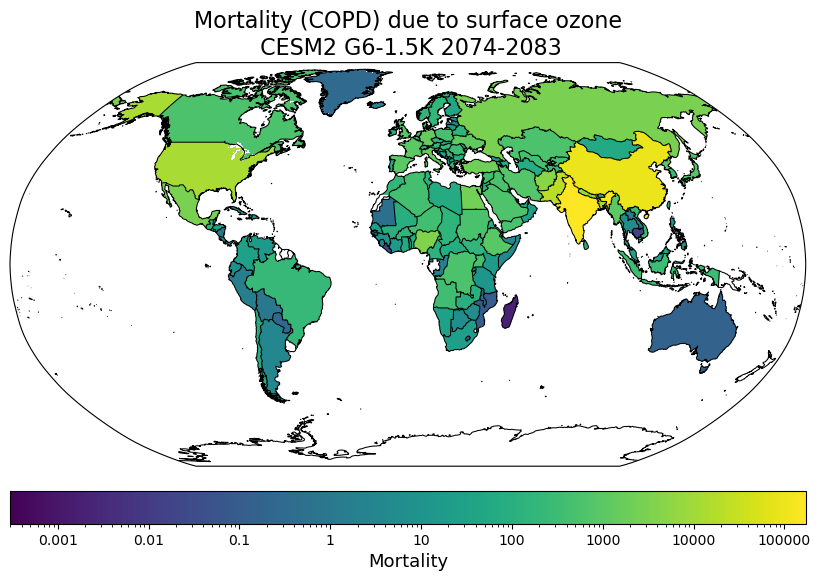

In [18]:
# === Scenario and path config ===
# Set to whatever scenario and model you want
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Country_level/"

model = "CESM2"
scenario = "G6-1.5K"

config = get_scenario_config(model, scenario)

da, first_year, last_year = process_mortality_for_plotting(model, scenario, config)

da_global = create_global_country_map(da)

# Plotting
plot_country_level_mortality(da_global, model, scenario, first_year, last_year, SAVE_DIR)

In [16]:
def plot_difference_country_level_mortality(da, model, scenario, start_year, end_year, levels, SAVE_DIR):
    # Create figure
    fig = plt.figure(figsize=autosize_figure(1, 1))
    gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    # First panel
    ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
    cb = land_filter(da).plot(
        transform=crs,
        levels=levels,
        add_colorbar=False,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"Mortality (COPD) due to surface ozone\n {model} {scenario} {start_year}-{end_year}", fontsize=16)

    # First colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
    col_bar.set_label("Mortality", fontsize=13)

    plt.tight_layout()

    out_file = f"Mortality_country_{model}_{scenario}_{start_year}-{end_year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

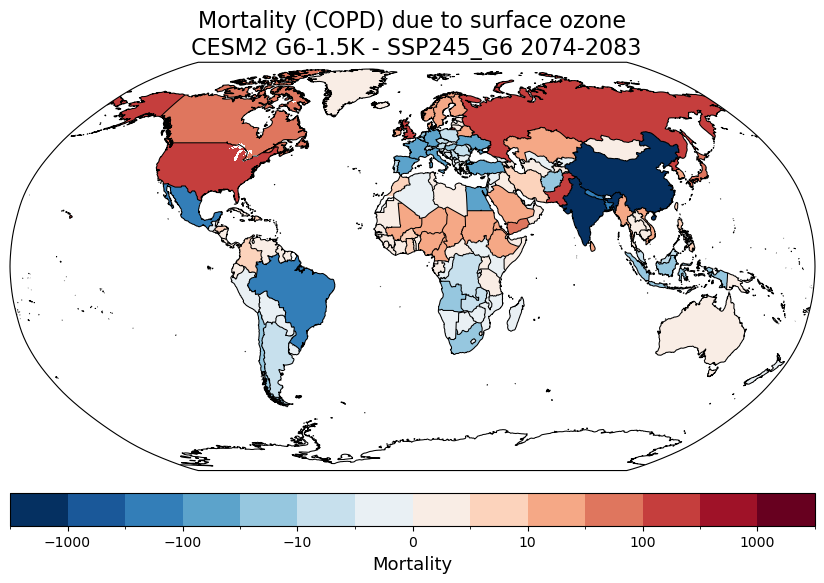

In [17]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Country_level/"

model = "CESM2"
scenario = ["G6-1.5K", "SSP245_G6"]
scenario_name = f"{scenario[0]} - {scenario[1]}"  # Check this is the way round you want it

config1 = get_scenario_config(model, scenario[0])
config2 = get_scenario_config(model, scenario[1])

da1, first_year1, last_year1 = process_mortality_for_plotting(model, scenario[0], config1)
da2, first_year2, last_year2 = process_mortality_for_plotting(model, scenario[1], config2)

da = da1 - da2  # Check this is the way round you want it

da_global = create_global_country_map(da)

# Assign levels for colorbar
levels = [-5000, -1000, -500, -100, -50, -10, -5, 0, 5, 10, 50, 100, 500, 1000, 5000]

# Plotting without ocean
plot_difference_country_level_mortality(da_global, model, scenario_name, first_year1, last_year1, levels, SAVE_DIR)